<a href="https://colab.research.google.com/github/ARMANDOTORRES81/r-basic/blob/master/Tarea_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Exploración BFS (Nivel por Nivel) ---
Orden de exploración: Inicio -> A -> B -> C -> D -> E -> Meta


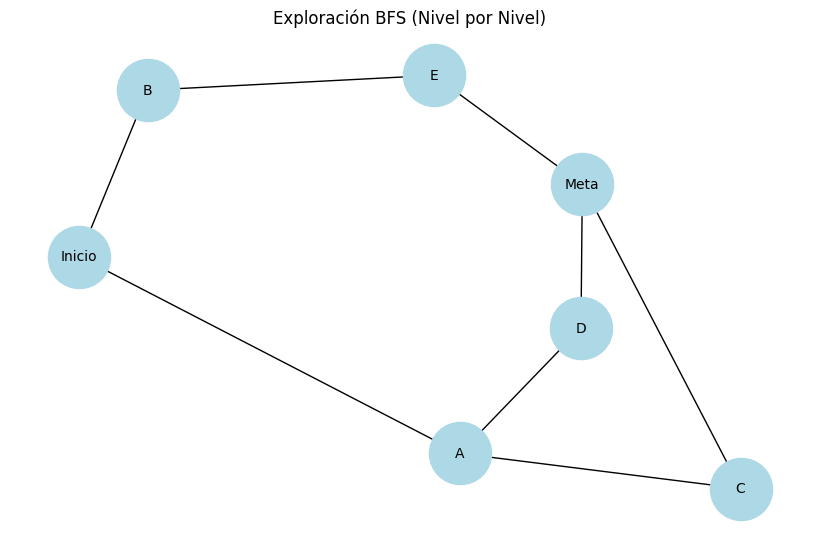

--- Exploración DFS (Hacia la Profundidad) ---
Orden de exploración: Inicio -> A -> C -> Meta


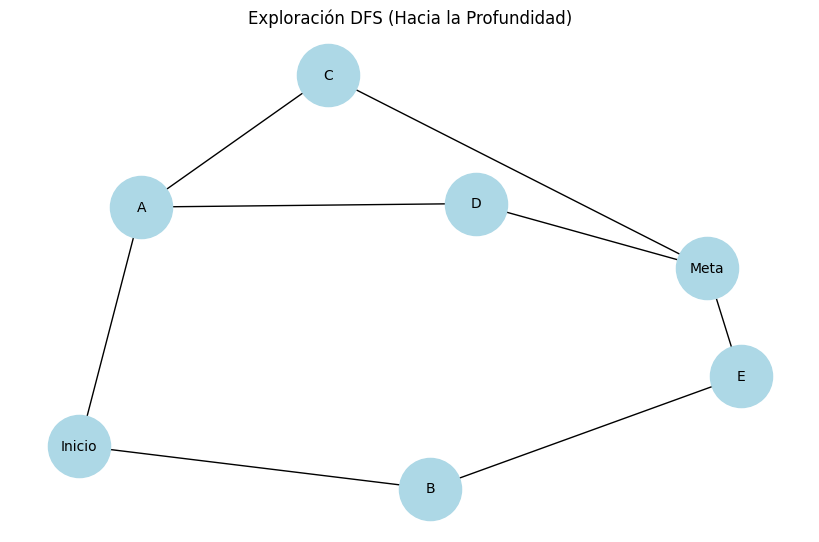

In [ ]:
import collections
import networkx as nx
import matplotlib.pyplot as plt

# 1. Definición del Espacio de Estados (Un grafo de una ciudad pequeña)
# Los nodos son puntos de control y las conexiones son calles con su costo (distancia)
graph = {
    'Inicio': [('A', 1), ('B', 4)],
    'A': [('Inicio', 1), ('C', 2), ('D', 5)],
    'B': [('Inicio', 4), ('E', 3)],
    'C': [('A', 2), ('Meta', 1)],
    'D': [('A', 5), ('Meta', 6)],
    'E': [('B', 3), ('Meta', 8)],
    'Meta': []
}

def visualize_search(visited_order, title):
    G = nx.Graph()
    for node, neighbors in graph.items():
        for neighbor, weight in neighbors:
            G.add_edge(node, neighbor, weight=weight)

    pos = nx.spring_layout(G)
    plt.figure(figsize=(8, 5))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2000, font_size=10)

    # Resaltar el orden de visita
    print(f"--- {title} ---")
    print("Orden de exploración:", " -> ".join(visited_order))
    plt.title(title)
    plt.show()

# 2. Implementación de BFS (Búsqueda en Amplitud)
def bfs(start, goal):
    queue = collections.deque([start])
    visited = []
    while queue:
        node = queue.popleft()
        if node not in visited:
            visited.append(node)
            if node == goal: break
            neighbors = [n[0] for n in graph.get(node, [])]
            queue.extend(neighbors)
    return visited

# 3. Implementación de DFS (Búsqueda en Profundidad)
def dfs(start, goal):
    stack = [start]
    visited = []
    while stack:
        node = stack.pop() # Sacamos el último (LIFO)
        if node not in visited:
            visited.append(node)
            if node == goal: break
            neighbors = [n[0] for n in graph.get(node, [])]
            stack.extend(reversed(neighbors))
    return visited

# Ejecución y Visualización
order_bfs = bfs('Inicio', 'Meta')
visualize_search(order_bfs, "Exploración BFS (Nivel por Nivel)")

order_dfs = dfs('Inicio', 'Meta')
visualize_search(order_dfs, "Exploración DFS (Hacia la Profundidad)")